In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display


In [150]:
df_laadpark = pd.read_csv('data/ev_consumption.csv', parse_dates=['Date'])
df_2024 = pd.read_excel('data/energie_orac_2024.xlsx', parse_dates=['datetime'])
df_2025 = pd.read_excel('data/energie_orac_2025.xlsx', parse_dates=['datetime'])
df_2026 = pd.read_excel('data/energie_orac_2026.xlsx', parse_dates=['datetime'])
df_laadsessies = pd.read_excel('data/Sessions (1) (1).xlsx', parse_dates=['From', 'To'])

In [151]:
df_laadpark.head()

,Date,total_consumption_ev
0,2025-05-06 00:00:00,0.005
1,2025-05-06 01:00:00,0.006
2,2025-05-06 02:00:00,0.006
3,2025-05-06 03:00:00,0.006
4,2025-05-06 04:00:00,0.006


In [152]:
df_2024.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,0.0
1,2024-01-01 00:15:00,10.625,0.0,0.0
2,2024-01-01 00:30:00,11.875,0.0,0.0
3,2024-01-01 00:45:00,13.750,0.0,0.0
4,2024-01-01 01:00:00,14.375,0.0,0.0


In [153]:
#aantal rijen in df_laadsessies
print(len(df_laadsessies))


3608


In [154]:
#resample df_2024, df_2025, df_2026 to 1h 
df_2024.set_index('datetime', inplace=True)
df_2024 = df_2024.resample('1h').sum()
df_2025.set_index('datetime', inplace=True)
df_2025 = df_2025.resample('1h').sum()
df_2026.set_index('datetime', inplace=True)
df_2026 = df_2026.resample('1h').sum()

In [155]:
df_2024.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2024-01-01 00:00:00,46.875,0.0,0.0
2024-01-01 01:00:00,54.375,0.0,0.0
2024-01-01 02:00:00,51.875,0.0,0.0
2024-01-01 03:00:00,53.125,0.0,0.0
2024-01-01 04:00:00,71.875,0.0,0.0


In [156]:
print(df_2024["injectie_kwh"].sum())

529468.26


In [157]:
df_2024.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2024-01-01 00:00:00,46.875,0.0,0.0
2024-01-01 01:00:00,54.375,0.0,0.0
2024-01-01 02:00:00,51.875,0.0,0.0
2024-01-01 03:00:00,53.125,0.0,0.0
2024-01-01 04:00:00,71.875,0.0,0.0


In [158]:
df_laadpark.head()

,Date,total_consumption_ev
0,2025-05-06 00:00:00,0.005
1,2025-05-06 01:00:00,0.006
2,2025-05-06 02:00:00,0.006
3,2025-05-06 03:00:00,0.006
4,2025-05-06 04:00:00,0.006


In [159]:
# Startdatums bepalen
df_laadpark['Date'] = pd.to_datetime(df_laadpark['Date'])
df_laadpark = df_laadpark.set_index('Date')

start_2024 = df_2024.index.min()
start_laadpark = df_laadpark.index.min()

offset = start_laadpark - start_2024

df_2024_shifted = df_2024.copy()
df_2024_shifted.index = df_2024_shifted.index + offset

print("Originele start:", start_2024)
print("Nieuwe start:", df_2024_shifted.index.min())
print("Laadpark start:", start_laadpark)

Originele start: 2024-01-01 00:00:00
Nieuwe start: 2025-05-06 00:00:00
Laadpark start: 2025-05-06 00:00:00


In [160]:
df_2024_shifted.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2025-05-06 00:00:00,46.875,0.0,0.0
2025-05-06 01:00:00,54.375,0.0,0.0
2025-05-06 02:00:00,51.875,0.0,0.0
2025-05-06 03:00:00,53.125,0.0,0.0
2025-05-06 04:00:00,71.875,0.0,0.0


In [161]:
df_2025_2026 = pd.concat([df_2025, df_2026])
df_2025_2026.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2025-01-01 00:00:00,43.125,0.0,0.0
2025-01-01 01:00:00,47.500,0.0,0.0
2025-01-01 02:00:00,53.125,0.0,0.0
2025-01-01 03:00:00,50.000,0.0,0.0
2025-01-01 04:00:00,65.625,0.0,0.0


In [162]:
start_ev = df_laadpark.index.min()
end_ev = df_laadpark.index.max()

start_2025_2026 = df_2025_2026.index.min()

offset = start_ev - start_2025_2026

df_2025_2026_shifted = df_2025_2026.copy()
df_2025_2026_shifted.index = df_2025_2026_shifted.index + offset

df_2025_2026_shifted = df_2025_2026_shifted.loc[start_ev:end_ev]

In [163]:
df_2025_2026_shifted.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2025-05-06 00:00:00,43.125,0.0,0.0
2025-05-06 01:00:00,47.500,0.0,0.0
2025-05-06 02:00:00,53.125,0.0,0.0
2025-05-06 03:00:00,50.000,0.0,0.0
2025-05-06 04:00:00,65.625,0.0,0.0


In [164]:
df_2024_clean = df_2024_shifted[['injectie_kwh', 'productie_kwh']].copy()
df_2025_2026_clean = df_2025_2026_shifted[['afname_kwh']].copy()
df_laadpark_clean = df_laadpark[['total_consumption_ev']].copy()

In [165]:
df_main = (
    df_2024_clean
    .join(df_2025_2026_clean, how='outer')
    .join(df_laadpark_clean, how='outer')
    .sort_index()
)

In [166]:
df_main = df_main.loc[df_laadpark.index.min():df_laadpark.index.max()]

In [167]:
df_main.head(50)

,injectie_kwh,productie_kwh,afname_kwh,total_consumption_ev
datetime,,,,
2025-05-06 00:00:00,0.00,0.000000,43.125,0.005
2025-05-06 01:00:00,0.00,0.000000,47.500,0.006
2025-05-06 02:00:00,0.00,0.000000,53.125,0.006
2025-05-06 03:00:00,0.00,0.000000,50.000,0.006
2025-05-06 04:00:00,0.00,0.000000,65.625,0.006
2025-05-06 05:00:00,0.00,0.000000,65.625,0.006
2025-05-06 06:00:00,0.00,0.000000,56.875,0.006
2025-05-06 07:00:00,0.00,0.000000,61.250,3.147
2025-05-06 08:00:00,0.00,0.413450,59.375,55.231


In [168]:
#Print injectie sum & laadverbruik sum en afronden en kwh erbij zetten
injectie_sum = df_main['injectie_kwh'].sum()
laadverbruik_sum = df_main['total_consumption_ev'].sum()
print(f"Totale injectie: {injectie_sum:.2f} kWh")
print(f"Totale laadverbruik: {laadverbruik_sum:.2f} kWh")

Totale injectie: 528396.32 kWh
Totale laadverbruik: 106465.10 kWh


In [169]:
df_main["totaal_verbruik_kwh"] = df_main['afname_kwh'] + df_main['productie_kwh'] - df_main['injectie_kwh']

In [170]:
df_main['totaal_verbruik_gebouw'] = df_main['totaal_verbruik_kwh'] - df_main['total_consumption_ev']
df_main.head()

,injectie_kwh,productie_kwh,afname_kwh,total_consumption_ev,totaal_verbruik_kwh,totaal_verbruik_gebouw
datetime,,,,,,
2025-05-06 00:00:00,0.0,0.0,43.125,0.005,43.125,43.120
2025-05-06 01:00:00,0.0,0.0,47.500,0.006,47.500,47.494
2025-05-06 02:00:00,0.0,0.0,53.125,0.006,53.125,53.119
2025-05-06 03:00:00,0.0,0.0,50.000,0.006,50.000,49.994
2025-05-06 04:00:00,0.0,0.0,65.625,0.006,65.625,65.619


In [171]:
df_main.head()

,injectie_kwh,productie_kwh,afname_kwh,total_consumption_ev,totaal_verbruik_kwh,totaal_verbruik_gebouw
datetime,,,,,,
2025-05-06 00:00:00,0.0,0.0,43.125,0.005,43.125,43.120
2025-05-06 01:00:00,0.0,0.0,47.500,0.006,47.500,47.494
2025-05-06 02:00:00,0.0,0.0,53.125,0.006,53.125,53.119
2025-05-06 03:00:00,0.0,0.0,50.000,0.006,50.000,49.994
2025-05-06 04:00:00,0.0,0.0,65.625,0.006,65.625,65.619


In [172]:
# ============================================================
# CEL 3 – PARAMETERS (GEFIXTE VERSIE)
# ============================================================

# --- Tijdinstellingen ---
TIJDSTAP_MIN = 60
TIJDSTAP_H = TIJDSTAP_MIN / 60

# --- EV & laadpark ---
N_EV_VLOOT = 35
N_LAADPUNTEN = 20
P_MAX_PUNT_KW = 11

P_MAX_TOTAAL = N_LAADPUNTEN * P_MAX_PUNT_KW  # 220 kW theoretisch max

AANKOMST_H = 8.0
VERTREK_H = 17.0

# ============================================================
# NET PARAMETERS (FLUVIUS)
# ============================================================

P_NET_MAX_KW = 620  # contractueel toegangsvermogen

# Capaciteitstarief (maandpiek gebaseerd)
TARIEF_CAPACITEIT_EUR_PER_KW_MAAND = 3.01

# Toegangsvermogen (vaste netwerkcomponent indien van toepassing)
TARIEF_TOEGANG_EUR_PER_KW_MAAND = 4.52


# ============================================================
# ENERGIE PRIJZEN (€/kWh)
# ============================================================

KLIK_INDEX = 89.737065  # €/MWh

# Energie (markt + levering)
TARIEF_PIEK_URU = KLIK_INDEX * 0.0014136 + 0.0075913
TARIEF_DAL_URU  = KLIK_INDEX * 0.0010510 + 0.0075913

# Netkosten & heffingen
KOST_GROENE_STROOM = 0.0110000
KOST_WKK = 0.0040810
BIJZONDERE_ACCIJNS = 0.0110018
ODV_PIEK = 0.0037033
ODV_DAL = 0.0037033
TOESLAG_E801 = 0.0002193

VASTE_EXTRA = (
    KOST_GROENE_STROOM +
    KOST_WKK +
    BIJZONDERE_ACCIJNS +
    TOESLAG_E801
)

TARIEF_AFNAME_PIEK = TARIEF_PIEK_URU + ODV_PIEK + VASTE_EXTRA
TARIEF_AFNAME_DAL  = TARIEF_DAL_URU  + ODV_DAL  + VASTE_EXTRA

TARIEF_AFNAME_GEM = 0.1761


# ============================================================
# INJECTIE (PV EXPORT)
# ============================================================

TARIEF_INJECTIE_GEM = ((57.98 - 15.58) +
                       (74.53 - 14.83) +
                       (74.795 - 14.75)) / 3 / 1000


# ============================================================
# PIEK DEFINITIE
# ============================================================

def is_piekuur(index):
    return (index.dayofweek < 5) & (index.hour >= 7) & (index.hour < 22)


# ============================================================
# COST MODEL FUNCTIES
# ============================================================

def bereken_maandpiek(df, column="P_net_kW"):
    """
    Berekent maandelijkse piek (Fluvius capaciteitstarief basis)
    """
    return df[column].resample("M").max()


def bereken_capaciteitstarief_kost(maandpiek_series):
    """
    €/kW/maand * maandpiek
    """
    return maandpiek_series * TARIEF_CAPACITEIT_EUR_PER_KW_MAAND


def bereken_toegangstarief_kost():
    """
    Vast vermogen kost (indien toegepast)
    """
    return P_NET_MAX_KW * TARIEF_TOEGANG_EUR_PER_KW_MAAND


def totale_netkost(df):
    """
    Volledig Fluvius kostenmodel
    """
    maandpiek = bereken_maandpiek(df)

    capaciteit = bereken_capaciteitstarief_kost(maandpiek).sum()
    toegang = bereken_toegangstarief_kost()

    return capaciteit + toegang


# ============================================================
# OUTPUT INFO
# ============================================================

print("=" * 50)
print(f"EV's: {N_EV_VLOOT} | Laadpunten: {N_LAADPUNTEN}")
print(f"Max laadvermogen: {P_MAX_TOTAAL} kW")
print(f"Netgrens: {P_NET_MAX_KW} kW")
print(f"Capaciteitstarief: {TARIEF_CAPACITEIT_EUR_PER_KW_MAAND} €/kW/maand")
print(f"Toegangstarief: {TARIEF_TOEGANG_EUR_PER_KW_MAAND} €/kW/maand")
print("=" * 50)

EV's: 35 | Laadpunten: 20
Max laadvermogen: 220 kW
Netgrens: 620 kW
Capaciteitstarief: 3.01 €/kW/maand
Toegangstarief: 4.52 €/kW/maand


In [173]:
N_LAADPUNTEN = 20
P_MAX_PUNT_KW = 11
P_MAX_TOTAAL = 220

def strategie_1_ongecoordineerd(df, n_laadpunten, p_max_punt, laadbehoefte_serie):
    """
    Aangepast: gebruikt nu laadbehoefte_serie in plaats van de hardcoded kolom
    """
    p_max = n_laadpunten * p_max_punt
    P_laad = pd.Series(0.0, index=df.index)

    werkdagen = df.index[df.index.dayofweek < 5].normalize().unique()

    for dag in werkdagen:
        mask_dag = df.index.normalize() == dag
        mask_aanwezig = mask_dag & (df.index.hour >= int(AANKOMST_H)) & (df.index.hour < int(VERTREK_H))
        idx_dag = df.index[mask_aanwezig]

        if len(idx_dag) == 0:
            continue

        # Gebruik hier de variabele laadbehoefte_serie in plaats van df['total_consumption_ev']
        energie_nodig = laadbehoefte_serie.loc[idx_dag].sum()
        energie_geladen = 0.0

        for t in idx_dag:
            energie_tekort = max(0.0, energie_nodig - energie_geladen)
            if energie_tekort <= 0:
                break

            p = min(p_max, energie_tekort / TIJDSTAP_H)
            P_laad[t] = p
            energie_geladen += p * TIJDSTAP_H

    return P_laad.rename('P_laad_S1')

In [174]:
# 1. Gebruik voor je HUIDIGE S1 gewoon de échte, gemeten EV data (niet simuleren!)
df_main['P_laad_S1'] = df_main['total_consumption_ev']

# 2. FIX: Bereken de S1 afname eerlijk via de formule (NIET de ruwe afname_kwh gebruiken!)
df_main['P_net_S1'] = (
    df_main['totaal_verbruik_gebouw'] 
    + df_main['P_laad_S1'] 
    - df_main['productie_kwh']
)

In [175]:
df_main.head()

,injectie_kwh,productie_kwh,afname_kwh,total_consumption_ev,totaal_verbruik_kwh,totaal_verbruik_gebouw,P_laad_S1,P_net_S1
datetime,,,,,,,,
2025-05-06 00:00:00,0.0,0.0,43.125,0.005,43.125,43.120,0.005,43.125
2025-05-06 01:00:00,0.0,0.0,47.500,0.006,47.500,47.494,0.006,47.500
2025-05-06 02:00:00,0.0,0.0,53.125,0.006,53.125,53.119,0.006,53.125
2025-05-06 03:00:00,0.0,0.0,50.000,0.006,50.000,49.994,0.006,50.000
2025-05-06 04:00:00,0.0,0.0,65.625,0.006,65.625,65.619,0.006,65.625


In [176]:
import math
import pandas as pd

def strategie_2_smart_zc(df, n_laadpunten, p_max_punt, laadbehoefte_serie):
    p_max = n_laadpunten * p_max_punt
    P_laad = pd.Series(0.0, index=df.index)

    werkdagen = df.index[df.index.dayofweek < 5].normalize().unique()

    for dag in werkdagen:
        mask_dag = (df.index.normalize() == dag)
        mask_aanwezig = mask_dag & (df.index.hour >= int(AANKOMST_H)) & (df.index.hour < int(VERTREK_H))
        idx_dag = df.index[mask_aanwezig]

        if len(idx_dag) == 0:
            continue

        energie_nodig = laadbehoefte_serie.loc[idx_dag].sum()
        energie_geladen = 0.0
        stappen_rest = len(idx_dag)

        for t in idx_dag:
            pv_overschot = max(0.0, df.loc[t, 'productie_kwh'] - df.loc[t, 'totaal_verbruik_gebouw'])
            energie_tekort = max(0.0, energie_nodig - energie_geladen)
            
            if energie_tekort <= 0:
                stappen_rest -= 1
                continue
                
            # NIEUWE LOGICA S2: Pure zonne-spons, tot het écht niet anders kan!
            # 1. Hoeveel tijdstappen hebben we nog minimaal nodig als we op MAXIMAAL vermogen laden?
            tijd_nodig_h = energie_tekort / p_max
            stappen_nodig_op_max = math.ceil(tijd_nodig_h / TIJDSTAP_H)
            
            # 2. Beslissen hoe we laden:
            if stappen_rest <= stappen_nodig_op_max:
                # We komen in tijdnood! Als we nu niet vol aanzetten, halen we de target niet voor vertrek.
                # Trek maximaal van het net (of zon, wat er is).
                p = p_max
            else:
                # We hebben nog genoeg tijd. We proberen uitsluitend 'gratis' zonne-overschot te laden.
                p = pv_overschot
                
            # 3. Zorg dat we nooit sneller laden dan de paal kan, of meer dan nog nodig is.
            vermogen_target = min(p_max, energie_tekort / TIJDSTAP_H)
            p = min(p, vermogen_target)

            P_laad[t] = p
            energie_geladen += p * TIJDSTAP_H
            stappen_rest -= 1

    return P_laad.rename('P_laad_S2')

# Roep de functie aan
df_main['P_laad_S2'] = strategie_2_smart_zc(
    df_main, 
    n_laadpunten=N_LAADPUNTEN, 
    p_max_punt=P_MAX_PUNT_KW,
    laadbehoefte_serie=df_main['total_consumption_ev']
)

# Netto-balans berekenen
df_main['P_net_S2'] = (
    df_main['totaal_verbruik_gebouw']
    + df_main['P_laad_S2']
    - df_main['productie_kwh']
)

In [177]:
def strategie_3_smart_zc_piek(df, n_laadpunten, p_max_punt, p_net_cap, laad_basis_col='P_laad_S1'):
    p_max = n_laadpunten * p_max_punt
    P_laad = pd.Series(0.0, index=df.index)

    if isinstance(laad_basis_col, str):
        laad_basis_series = df[laad_basis_col]
    else:
        laad_basis_series = laad_basis_col

    werkdagen = df.index[df.index.dayofweek < 5].normalize().unique()

    for dag in werkdagen:
        mask_dag = (df.index.normalize() == dag)
        mask_aanwezig = mask_dag & (df.index.hour >= int(AANKOMST_H)) & (df.index.hour < int(VERTREK_H))
        idx_dag = df.index[mask_aanwezig]

        if len(idx_dag) == 0:
            continue

        # FIX: Omdat laad_basis_series (S1) nu direct de echte data in kWh is,
        # is de .sum() voldoende. We hoeven NIET te vermenigvuldigen met TIJDSTAP_H.
        energie_nodig = laad_basis_series.loc[idx_dag].sum()
        energie_geladen = 0.0
        stappen_rest = len(idx_dag)

        for t in idx_dag:
            pv_overschot = max(0.0, df.loc[t, 'productie_kwh'] - df.loc[t, 'totaal_verbruik_gebouw'])
            net_zonder_ev = df.loc[t, 'totaal_verbruik_gebouw'] - df.loc[t, 'productie_kwh']
            energie_tekort = max(0.0, energie_nodig - energie_geladen)
            
            if energie_tekort <= 0:
                stappen_rest -= 1
                continue
            
            # Het minimale vermogen om de auto netjes vol te krijgen (mooi uitsmeren net als in S2)
            minimum_nodig = (energie_tekort / TIJDSTAP_H) / stappen_rest if stappen_rest > 0 else 0.0
            vermogen_target = min(p_max, energie_tekort / TIJDSTAP_H)

            # Hoeveel ruimte is er nog voordat we de gebouwpiek (p_net_cap) overschrijden?
            # Handig: als er veel zon is, is net_zonder_ev negatief, waardoor p_cap STIJGT. 
            p_cap = max(0.0, p_net_cap - net_zonder_ev)

            # Basis laden: we volgen de zon OF we laden het strikte minimum dat nodig is
            p = max(pv_overschot, minimum_nodig) 
            
            # Peak Shaving logica:
            if p > p_cap and minimum_nodig <= p_cap:
                # Beperk het laden tot de beschikbare netruimte (p_cap), 
                # TENZIJ we de cap móéten breken om de EV vol te krijgen (minimum_nodig).
                p = p_cap
                
            # Zorg dat we nooit fysiek sneller laden dan de palen aankunnen of we nodig hebben
            p = min(p, vermogen_target)

            P_laad[t] = max(0.0, p)
            energie_geladen += P_laad[t] * TIJDSTAP_H
            stappen_rest -= 1

    # P_net niet meer clippen, we willen de échte netto balans zien in de KPI's
    P_net = df['totaal_verbruik_gebouw'] + P_laad - df['productie_kwh']

    return P_laad.rename('P_laad_S3'), P_net.rename('P_net_S3')

In [178]:
P_NET_CAP = 605  # Of 580, afhankelijk van je definitieve keuze

df_main['P_laad_S3'], df_main['P_net_S3'] = strategie_3_smart_zc_piek(
    df_main,
    N_LAADPUNTEN,
    P_MAX_PUNT_KW,
    P_NET_CAP,
    laad_basis_col='P_laad_S1' # Kijkt naar de basis S1
)

In [179]:
# ============================================================
# EXTRA SCENARIO'S: +5 LAADPALEN (= +10 PUNTEN) EN +10 LAADPALEN (= +20 PUNTEN)
# ============================================================

def maak_extra_scenario(df, suffix, extra_laadpunten): # <-- Aangepast naar 'punten'
    # 1. Bereken de verhouding (bijv. 30 punten / 20 punten = 1.5)
    n_laadpunten = N_LAADPUNTEN + extra_laadpunten
    factor = n_laadpunten / N_LAADPUNTEN
    
    # 2. Maak een kopie van de laadvraag voor dit scenario
    laadvraag_scenario = df['total_consumption_ev'] * factor
    
    s1_col = f'P_laad_S1_{suffix}'
    s2_col = f'P_laad_S2_{suffix}'
    s3_col = f'P_laad_S3_{suffix}'

    # 3. Bereken S1 (Ongecoördineerd): 
    # We gebruiken de opgeschaalde échte meetdata om onrealistische pieken te voorkomen!
    df[s1_col] = laadvraag_scenario
    df[f'P_net_S1_{suffix}'] = df['totaal_verbruik_gebouw'] + df[s1_col] - df['productie_kwh']

    # 4. Bereken S2 (Smart ZC)
    df[s2_col] = strategie_2_smart_zc(df, n_laadpunten, P_MAX_PUNT_KW, laadvraag_scenario)
    df[f'P_net_S2_{suffix}'] = df['totaal_verbruik_gebouw'] + df[s2_col] - df['productie_kwh']

    # 5. Bereken S3 (Smart ZC + Piek)
    df[s3_col], df[f'P_net_S3_{suffix}'] = strategie_3_smart_zc_piek(
        df,
        n_laadpunten,
        P_MAX_PUNT_KW,
        P_NET_CAP,
        laad_basis_col=s1_col # S3 gebruikt de opgeschaalde S1 als basis
    )

    return [s1_col, s2_col, s3_col, f'P_net_S1_{suffix}', f'P_net_S2_{suffix}', f'P_net_S3_{suffix}']

# Roep de functie nu aan met het aantal EXTRA PUNTEN (10 en 20)
extra_kolommen_5_palen  = maak_extra_scenario(df_main, 'plus10p', 10) 
extra_kolommen_10_palen = maak_extra_scenario(df_main, 'plus20p', 20)

print('Extra scenario-kolommen aangemaakt ✓')

Extra scenario-kolommen aangemaakt ✓


In [180]:
import pandas as pd
from IPython.display import display

# ============================================================
# CONFIGURATIE BASELINE CONTRACT
# ============================================================
HUIDIG_TOEGANGSVERMOGEN = 620  # Jullie huidige vaste Fluvius contractcapaciteit

# ============================================================
# KPI FUNCTION
# ============================================================
def bereken_kpi(df, s_label, s_laad, s_net):

    # ============================================================
    # S0 BASELINE (GEBOUW ONLY, GEEN EV)
    # ============================================================
    if s_label == 'S0 – Geen EV':
        P_laad = pd.Series(0.0, index=df.index)
        P_net  = df['totaal_verbruik_gebouw'] - df['productie_kwh']
    else:
        P_laad = df[s_laad]
        P_net  = df[s_net]

    P_pv = df['productie_kwh']

    # ============================================================
    # ENERGIE
    # ============================================================
    E_laad = (P_laad * TIJDSTAP_H).sum()
    E_afname = (P_net.clip(lower=0) * TIJDSTAP_H).sum()
    P_piek = P_net.clip(lower=0).max()

    # ============================================================
    # PV – ZELFCONSUMPTIE
    # ============================================================
    pv_overschot_gebouw = (P_pv - df['totaal_verbruik_gebouw']).clip(lower=0)
    E_pv_naar_ev = (pd.concat([pv_overschot_gebouw, P_laad], axis=1).min(axis=1) * TIJDSTAP_H).sum()
    
    nieuw_totaal_verbruik = df['totaal_verbruik_gebouw'] + P_laad
    pv_lokaal = (pd.concat([P_pv, nieuw_totaal_verbruik], axis=1).min(axis=1) * TIJDSTAP_H).sum()
    
    E_pv_tot = (P_pv * TIJDSTAP_H).sum()

    zc_ev_pct = 100 * E_pv_naar_ev / E_laad if E_laad > 0 else 0
    zv_totaal_pct = 100 * pv_lokaal / E_pv_tot if E_pv_tot > 0 else 0

    # ============================================================
    # KOSTEN (PER MAAND & DYNAMISCH VANAF BASELINE)
    # ============================================================
    # FIX: Het toegangsvermogen is minimaal jullie huidige contract (620 kW).
    # Pas als de nieuwe piek + 20 kW marge hier bóvenuit komt, stijgt het vermogen.
    dynamische_toegang_kw = max(HUIDIG_TOEGANGSVERMOGEN, P_piek + 20) 

    CAP_KOST = P_piek * TARIEF_CAPACITEIT_EUR_PER_KW_MAAND
    TOEG_KOST = dynamische_toegang_kw * TARIEF_TOEGANG_EUR_PER_KW_MAAND

    PRICE_BEST = TARIEF_AFNAME_GEM
    PRICE_WORST = 0.16

    E_KOST_BEST = E_afname * PRICE_BEST
    E_KOST_WORST = E_afname * PRICE_WORST

    TOT_BEST = E_KOST_BEST + CAP_KOST + TOEG_KOST
    TOT_WORST = E_KOST_WORST + CAP_KOST + TOEG_KOST

    return {
        'Strategie': s_label,
        'E EV (kWh)': round(E_laad, 0),
        'E afname net (kWh)': round(E_afname, 0),
        'Piek net (kW)': round(P_piek, 1),
        'Toegangsvermogen (kW)': round(dynamische_toegang_kw, 1),
        'Zc EV (%)': round(zc_ev_pct, 1),           
        'Zv Totaal (%)': round(zv_totaal_pct, 1),   
        'Capaciteitskost (€/maand)': round(CAP_KOST, 0),
        'Toegangskost (€/maand)': round(TOEG_KOST, 0),
        'Totale kost BEST': round(TOT_BEST, 0),
        'Totale kost WORST': round(TOT_WORST, 0)
    }

# ============================================================
# KPI RUN
# ============================================================
kpi_data = [
    bereken_kpi(df_main, 'S0 – Geen EV', None, None),
    bereken_kpi(df_main, 'S1 – Ongecoördineerd', 'P_laad_S1', 'P_net_S1'),
    bereken_kpi(df_main, 'S2 – Smart ZC', 'P_laad_S2', 'P_net_S2'),
    bereken_kpi(df_main, 'S3 – ZC + Piek', 'P_laad_S3', 'P_net_S3'),
    bereken_kpi(df_main, 'S1 + 5 laadpalen', 'P_laad_S1_plus10p', 'P_net_S1_plus10p'),
    bereken_kpi(df_main, 'S2 + 5 laadpalen', 'P_laad_S2_plus10p', 'P_net_S2_plus10p'),
    bereken_kpi(df_main, 'S3 + 5 laadpalen', 'P_laad_S3_plus10p', 'P_net_S3_plus10p'),
    bereken_kpi(df_main, 'S1 + 10 laadpalen', 'P_laad_S1_plus20p', 'P_net_S1_plus20p'),
    bereken_kpi(df_main, 'S2 + 10 laadpalen', 'P_laad_S2_plus20p', 'P_net_S2_plus20p'),
    bereken_kpi(df_main, 'S3 + 10 laadpalen', 'P_laad_S3_plus20p', 'P_net_S3_plus20p')
]

kpi_df = pd.DataFrame(kpi_data).set_index('Strategie')

# ============================================================
# BESPARING VS S1
# ============================================================
s1 = kpi_df.loc['S1 – Ongecoördineerd']

kpi_df['Besparing BEST vs S1'] = s1['Totale kost BEST'] - kpi_df['Totale kost BEST']
kpi_df['Besparing WORST vs S1'] = s1['Totale kost WORST'] - kpi_df['Totale kost WORST']

kpi_df.loc['S1 – Ongecoördineerd', ['Besparing BEST vs S1', 'Besparing WORST vs S1']] = 0
kpi_df.loc['S0 – Geen EV', ['Besparing BEST vs S1', 'Besparing WORST vs S1']] = 0

# ============================================================
# OUTPUT
# ============================================================
cols = [
    'E EV (kWh)',
    'E afname net (kWh)',
    'Piek net (kW)',
    'Toegangsvermogen (kW)',
    'Zc EV (%)',
    'Zv Totaal (%)',
    'Capaciteitskost (€/maand)',
    'Toegangskost (€/maand)',
    'Besparing BEST vs S1',
    'Besparing WORST vs S1'
]

display(kpi_df[cols].T)

Strategie,S0 – Geen EV,S1 – Ongecoördineerd,S2 – Smart ZC,S3 – ZC + Piek,S1 + 5 laadpalen,S2 + 5 laadpalen,S3 + 5 laadpalen,S1 + 10 laadpalen,S2 + 10 laadpalen,S3 + 10 laadpalen
E EV (kWh),0.0,106465.0,101226.0,101226.0,159698.0,151839.0,151839.0,212930.0,202452.0,202452.0
E afname net (kWh),1577934.0,1634841.0,1616207.0,1623587.0,1672953.0,1643288.0,1653149.0,1712810.0,1672601.0,1685117.0
Piek net (kW),587.5,598.1,727.2,587.5,664.5,837.2,617.9,750.8,947.2,665.2
Toegangsvermogen (kW),620.0,620.0,747.2,620.0,684.5,857.2,637.9,770.8,967.2,685.2
Zc EV (%),0.0,46.5,62.2,54.9,40.5,57.0,50.5,36.7,53.2,47.1
Zv Totaal (%),60.2,64.3,65.4,64.8,65.5,67.3,66.5,66.6,69.1,68.0
Capaciteitskost (€/maand),1768.0,1800.0,2189.0,1768.0,2000.0,2520.0,1860.0,2260.0,2851.0,2002.0
Toegangskost (€/maand),2802.0,2802.0,3377.0,2802.0,3094.0,3874.0,2883.0,3484.0,4372.0,3097.0
Besparing BEST vs S1,0.0,0.0,2318.0,2013.0,-7203.0,-3279.0,-3365.0,-14872.0,-9270.0,-9350.0
Besparing WORST vs S1,0.0,0.0,2018.0,1832.0,-6589.0,-3143.0,-3070.0,-13616.0,-8662.0,-8541.0


In [184]:
import pandas as pd
from IPython.display import display, HTML

# ============================================================
# CONFIGURATIE BASELINE CONTRACT
# ============================================================
HUIDIG_TOEGANGSVERMOGEN = 620  # Jullie huidige vaste Fluvius contractcapaciteit

# ============================================================
# KPI FUNCTION
# ============================================================
def bereken_kpi(df, s_label, s_laad, s_net):
    if s_label == 'S0 – Geen EV':
        P_laad = pd.Series(0.0, index=df.index)
        P_net  = df['totaal_verbruik_gebouw'] - df['productie_kwh']
    else:
        P_laad = df[s_laad]
        P_net  = df[s_net]

    P_pv = df['productie_kwh']

    E_laad = (P_laad * TIJDSTAP_H).sum()
    E_afname = (P_net.clip(lower=0) * TIJDSTAP_H).sum()
    P_piek = P_net.clip(lower=0).max()

    pv_overschot_gebouw = (P_pv - df['totaal_verbruik_gebouw']).clip(lower=0)
    E_pv_naar_ev = (pd.concat([pv_overschot_gebouw, P_laad], axis=1).min(axis=1) * TIJDSTAP_H).sum()
    
    nieuw_totaal_verbruik = df['totaal_verbruik_gebouw'] + P_laad
    pv_lokaal = (pd.concat([P_pv, nieuw_totaal_verbruik], axis=1).min(axis=1) * TIJDSTAP_H).sum()
    
    E_pv_tot = (P_pv * TIJDSTAP_H).sum()

    zc_ev_pct = 100 * E_pv_naar_ev / E_laad if E_laad > 0 else 0
    zv_totaal_pct = 100 * pv_lokaal / E_pv_tot if E_pv_tot > 0 else 0

    dynamische_toegang_kw = max(HUIDIG_TOEGANGSVERMOGEN, P_piek + 20) 

    CAP_KOST = P_piek * TARIEF_CAPACITEIT_EUR_PER_KW_MAAND
    TOEG_KOST = dynamische_toegang_kw * TARIEF_TOEGANG_EUR_PER_KW_MAAND

    PRICE_BEST = TARIEF_AFNAME_GEM
    PRICE_WORST = 0.16

    E_KOST_BEST = E_afname * PRICE_BEST
    E_KOST_WORST = E_afname * PRICE_WORST

    TOT_BEST = E_KOST_BEST + CAP_KOST + TOEG_KOST
    TOT_WORST = E_KOST_WORST + CAP_KOST + TOEG_KOST

    return {
        'Strategie': s_label,
        'E EV (kWh)': round(E_laad, 0),
        'E afname net (kWh)': round(E_afname, 0),
        'Piek net (kW)': round(P_piek, 1),
        'Toegangsvermogen (kW)': round(dynamische_toegang_kw, 1),
        'Zc EV (%)': round(zc_ev_pct, 1),           
        'Zv Totaal (%)': round(zv_totaal_pct, 1),   
        'Capaciteitskost (€/maand)': round(CAP_KOST, 0),
        'Toegangskost (€/maand)': round(TOEG_KOST, 0),
        'Totale kost BEST': round(TOT_BEST, 0),
        'Totale kost WORST': round(TOT_WORST, 0)
    }

# ============================================================
# KPI RUN
# ============================================================
kpi_data = [
    bereken_kpi(df_main, 'S0 – Geen EV', None, None),
    bereken_kpi(df_main, 'S1 – Ongecoördineerd', 'P_laad_S1', 'P_net_S1'),
    bereken_kpi(df_main, 'S2 – Smart ZC', 'P_laad_S2', 'P_net_S2'),
    bereken_kpi(df_main, 'S3 – ZC + Piek', 'P_laad_S3', 'P_net_S3'),
    bereken_kpi(df_main, 'S1 + 5 laadpalen', 'P_laad_S1_plus10p', 'P_net_S1_plus10p'),
    bereken_kpi(df_main, 'S2 + 5 laadpalen', 'P_laad_S2_plus10p', 'P_net_S2_plus10p'),
    bereken_kpi(df_main, 'S3 + 5 laadpalen', 'P_laad_S3_plus10p', 'P_net_S3_plus10p'),
    bereken_kpi(df_main, 'S1 + 10 laadpalen', 'P_laad_S1_plus20p', 'P_net_S1_plus20p'),
    bereken_kpi(df_main, 'S2 + 10 laadpalen', 'P_laad_S2_plus20p', 'P_net_S2_plus20p'),
    bereken_kpi(df_main, 'S3 + 10 laadpalen', 'P_laad_S3_plus20p', 'P_net_S3_plus20p')
]

kpi_df = pd.DataFrame(kpi_data).set_index('Strategie')

# ============================================================
# OUTPUT FUNCTIE VOOR APARTE TABELLEN
# ============================================================
def toon_scenario_tabel(df, titel, labels, s1_label):
    # Selecteer alleen de rijen voor deze specifieke tabel
    sub_df = df.loc[labels].copy()
    
    # Bereken de besparing ten opzichte van de S1 uit DIT specifieke scenario
    s1_kosten_best = sub_df.loc[s1_label, 'Totale kost BEST']
    s1_kosten_worst = sub_df.loc[s1_label, 'Totale kost WORST']
    
    sub_df['Besparing BEST vs Ongecoördineerd'] = s1_kosten_best - sub_df['Totale kost BEST']
    sub_df['Besparing WORST vs Ongecoördineerd'] = s1_kosten_worst - sub_df['Totale kost WORST']
    
    # Zet de besparing van S1 logischerwijs op 0
    sub_df.loc[s1_label, ['Besparing BEST vs Ongecoördineerd', 'Besparing WORST vs Ongecoördineerd']] = 0
    
    # Bepaal welke kolommen we willen printen
    uitvoer_cols = [
        'E EV (kWh)',
        'E afname net (kWh)',
        'Piek net (kW)',
        'Toegangsvermogen (kW)',
        'Zc EV (%)',
        'Zv Totaal (%)',
        'Capaciteitskost (€/maand)',
        'Toegangskost (€/maand)',
        'Besparing BEST vs Ongecoördineerd',
        'Besparing WORST vs Ongecoördineerd'
    ]
    
    # Print de titel en de getransponeerde tabel
    display(HTML(f"<h3 style='color: #2c3e50;'>{titel}</h3>"))
    display(sub_df[uitvoer_cols].T)

# ============================================================
# TOON DE 3 TABELLEN
# ============================================================
# Tabel 1: Huidige Situatie
toon_scenario_tabel(
    kpi_df, 
    "Tabel 1: Huidige Situatie (20 Laadpalen)", 
    ['S0 – Geen EV', 'S1 – Ongecoördineerd', 'S2 – Smart ZC', 'S3 – ZC + Piek'], 
    'S1 – Ongecoördineerd'
)

# Tabel 2: + 5 Laadpalen
toon_scenario_tabel(
    kpi_df, 
    "Tabel 2: Uitbreiding met +5 Laadpalen", 
    ['S0 – Geen EV', 'S1 + 5 laadpalen', 'S2 + 5 laadpalen', 'S3 + 5 laadpalen'], 
    'S1 + 5 laadpalen'
)

# Tabel 3: + 10 Laadpalen
toon_scenario_tabel(
    kpi_df, 
    "Tabel 3: Uitbreiding met +10 Laadpalen", 
    ['S0 – Geen EV', 'S1 + 10 laadpalen', 'S2 + 10 laadpalen', 'S3 + 10 laadpalen'], 
    'S1 + 10 laadpalen'
)

Strategie,S0 – Geen EV,S1 – Ongecoördineerd,S2 – Smart ZC,S3 – ZC + Piek
E EV (kWh),0.0,106465.0,101226.0,101226.0
E afname net (kWh),1577934.0,1634841.0,1616207.0,1623587.0
Piek net (kW),587.5,598.1,727.2,587.5
Toegangsvermogen (kW),620.0,620.0,747.2,620.0
Zc EV (%),0.0,46.5,62.2,54.9
Zv Totaal (%),60.2,64.3,65.4,64.8
Capaciteitskost (€/maand),1768.0,1800.0,2189.0,1768.0
Toegangskost (€/maand),2802.0,2802.0,3377.0,2802.0
Besparing BEST vs Ongecoördineerd,10053.0,0.0,2318.0,2013.0
Besparing WORST vs Ongecoördineerd,9137.0,0.0,2018.0,1832.0


Strategie,S0 – Geen EV,S1 + 5 laadpalen,S2 + 5 laadpalen,S3 + 5 laadpalen
E EV (kWh),0.0,159698.0,151839.0,151839.0
E afname net (kWh),1577934.0,1672953.0,1643288.0,1653149.0
Piek net (kW),587.5,664.5,837.2,617.9
Toegangsvermogen (kW),620.0,684.5,857.2,637.9
Zc EV (%),0.0,40.5,57.0,50.5
Zv Totaal (%),60.2,65.5,67.3,66.5
Capaciteitskost (€/maand),1768.0,2000.0,2520.0,1860.0
Toegangskost (€/maand),2802.0,3094.0,3874.0,2883.0
Besparing BEST vs Ongecoördineerd,17256.0,0.0,3924.0,3838.0
Besparing WORST vs Ongecoördineerd,15726.0,0.0,3446.0,3519.0


Strategie,S0 – Geen EV,S1 + 10 laadpalen,S2 + 10 laadpalen,S3 + 10 laadpalen
E EV (kWh),0.0,212930.0,202452.0,202452.0
E afname net (kWh),1577934.0,1712810.0,1672601.0,1685117.0
Piek net (kW),587.5,750.8,947.2,665.2
Toegangsvermogen (kW),620.0,770.8,967.2,685.2
Zc EV (%),0.0,36.7,53.2,47.1
Zv Totaal (%),60.2,66.6,69.1,68.0
Capaciteitskost (€/maand),1768.0,2260.0,2851.0,2002.0
Toegangskost (€/maand),2802.0,3484.0,4372.0,3097.0
Besparing BEST vs Ongecoördineerd,24925.0,0.0,5602.0,5522.0
Besparing WORST vs Ongecoördineerd,22753.0,0.0,4954.0,5075.0


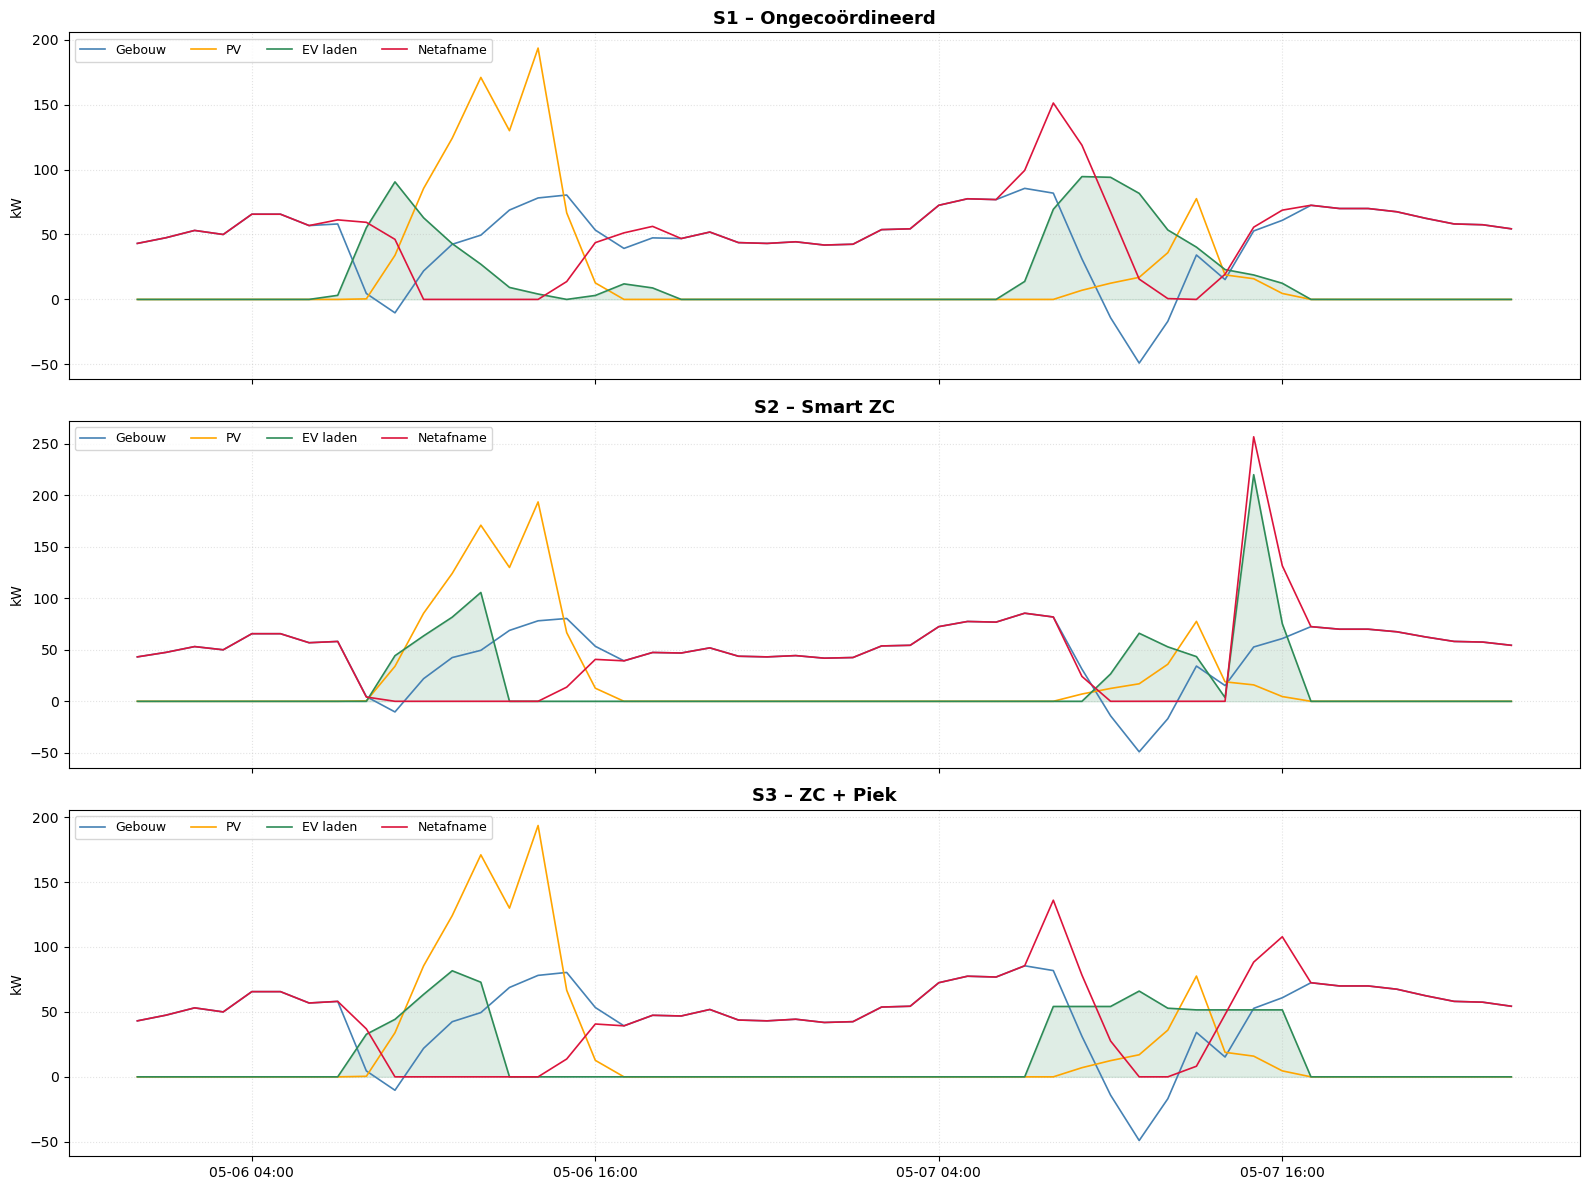

In [181]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ============================================================
# SIMULATIEGRAFIEK: S1 vs S2 vs S3
# ============================================================

start_plot = pd.Timestamp('2025-05-06 00:00:00')
eind_plot = start_plot + pd.Timedelta(days=2)
df_sim = df_main.loc[start_plot:eind_plot].copy()

strategie_plot = {
    'S1 – Ongecoördineerd': ('P_laad_S1', 'P_net_S1'),
    'S2 – Smart ZC': ('P_laad_S2', 'P_net_S2'),
    'S3 – ZC + Piek': ('P_laad_S3', 'P_net_S3'),
}

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (naam, (col_laad, col_net)) in zip(axes, strategie_plot.items()):
    gebouw = df_sim['totaal_verbruik_gebouw']
    pv = df_sim['productie_kwh']
    laad = df_sim[col_laad]
    net = df_sim[col_net]

    ax.plot(df_sim.index, gebouw, color='steelblue', linewidth=1.2, label='Gebouw')
    ax.plot(df_sim.index, pv, color='orange', linewidth=1.2, label='PV')
    ax.plot(df_sim.index, laad, color='seagreen', linewidth=1.2, label='EV laden')
    ax.plot(df_sim.index, net.clip(lower=0), color='crimson', linewidth=1.2, label='Netafname')

    ax.fill_between(df_sim.index, 0, laad, color='seagreen', alpha=0.15)
    ax.set_title(naam, fontsize=13, fontweight='bold')
    ax.set_ylabel('kW')
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.legend(loc='upper left', ncols=4, fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
plt.setp(axes[-1].get_xticklabels(), rotation=0, ha='center')
plt.tight_layout()
plt.show()

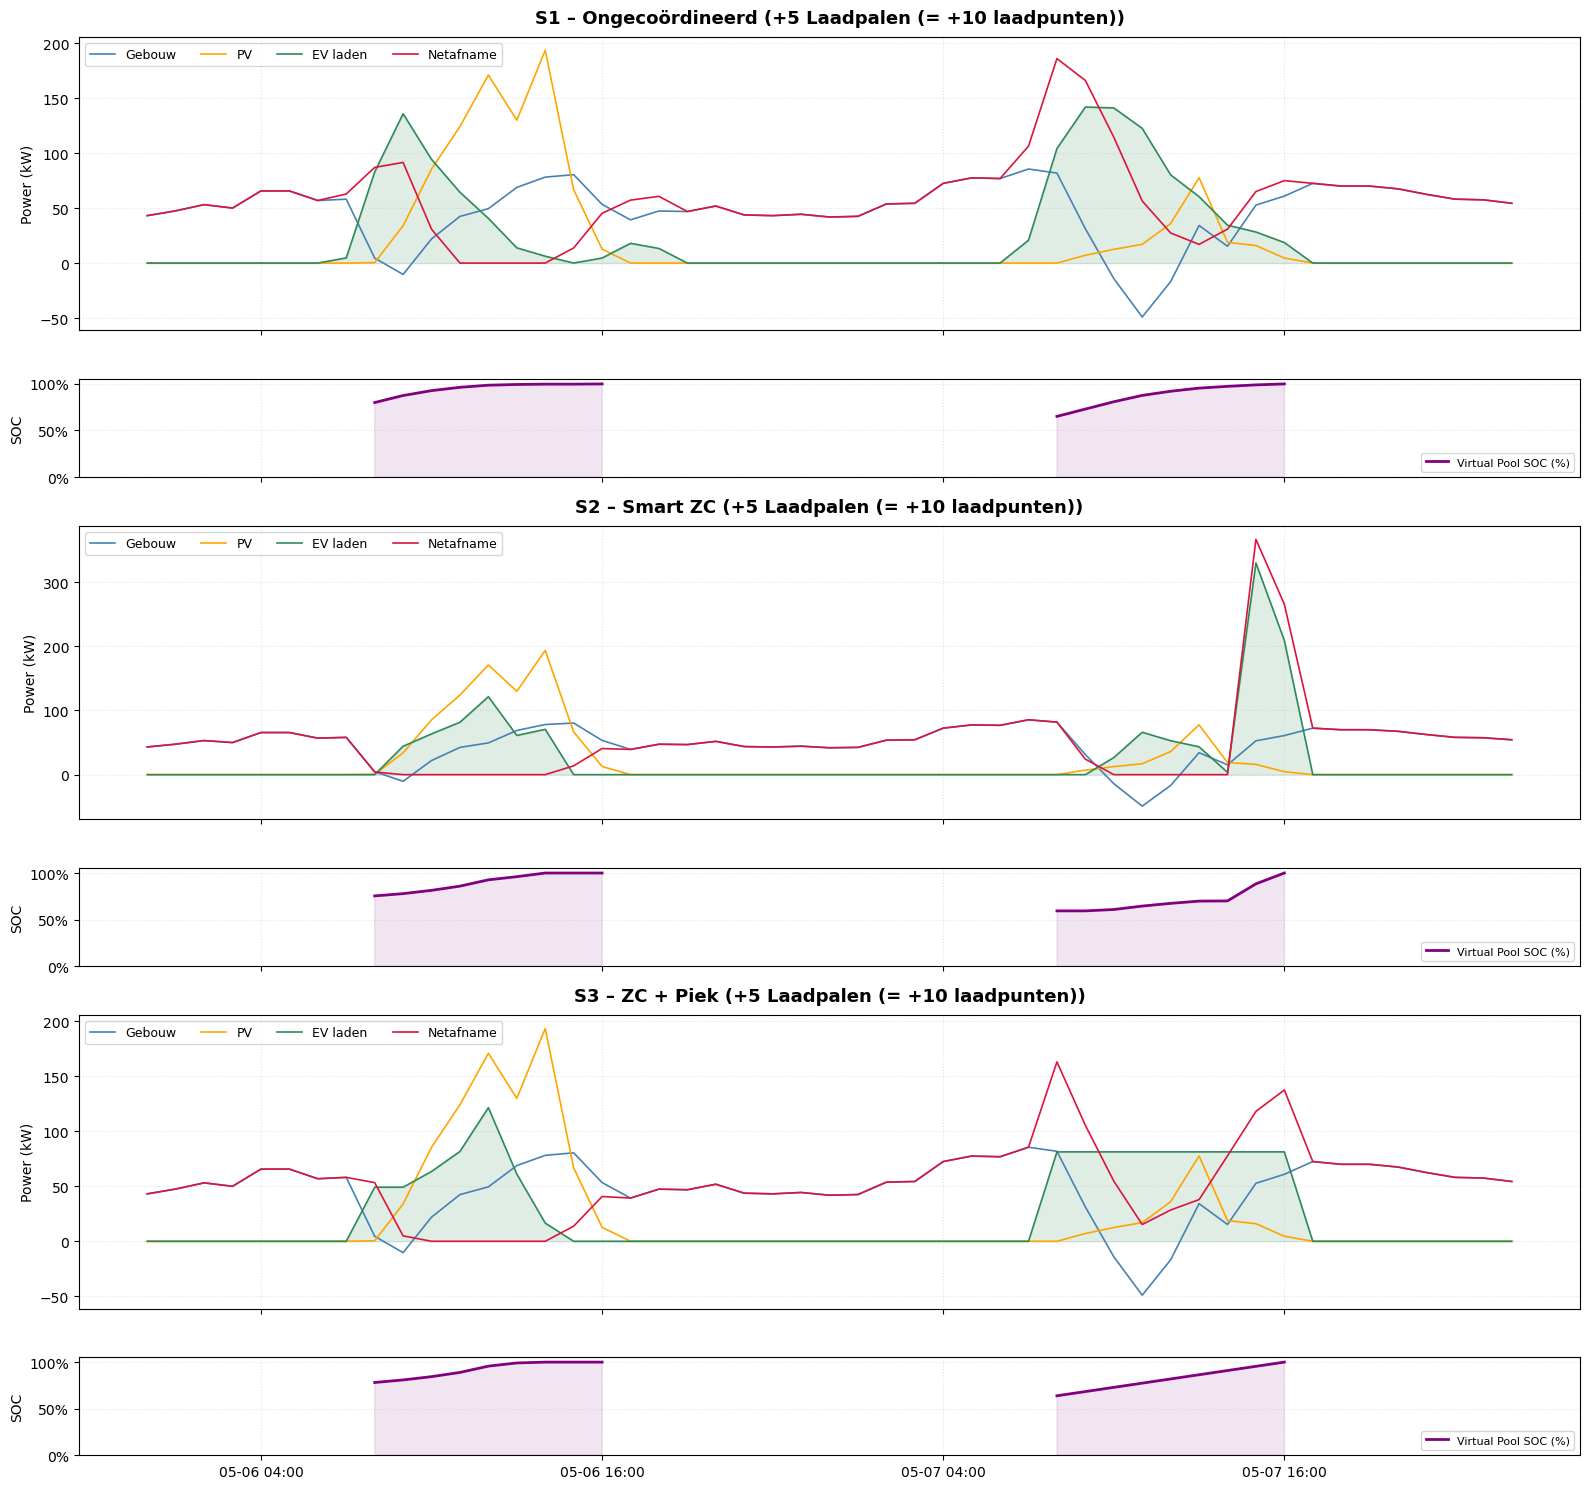

In [182]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np

# ============================================================
# INSTELLINGEN
# ============================================================
suffix_scenario = 'plus10p' 
naam_scenario = '+5 Laadpalen (= +10 laadpunten)' 
N_LAADPUNTEN_BASE = 20
EXTRA_LAADPUNTEN = 10
N_LAADPUNTEN_TOTAAL = N_LAADPUNTEN_BASE + EXTRA_LAADPUNTEN
TIJDSTAP_H = 1  # Verander dit naar 0.25 als je kwartierdata gebruikt!
ACCU_KWH_PER_AUTO = 60 # Aangenomen batterijgrootte per auto

# TOEGEVOEGD: Nodig om te bepalen wanneer de SOC-lijn getekend mag worden
AANKOMST_H = 8
VERTREK_H = 17

# Selecteer periode (2 dagen)
start_plot = pd.Timestamp('2025-05-06 00:00:00')
eind_plot = start_plot + pd.Timedelta(days=2)
df_sim = df_main.loc[start_plot:eind_plot].copy()

# ============================================================
# VIRTUELE SOC BEREKENING (Onzichtbaar buiten werktijd)
# ============================================================
def bereken_virtuele_soc(df_tijd, col_laad, n_punten):
    totale_pool_kwh = n_punten * ACCU_KWH_PER_AUTO
    
    # FIX: Start met 'np.nan' zodat de grafiek leeg is als de auto's er niet zijn
    soc_series = pd.Series(np.nan, index=df_tijd.index)
    
    # Gebruik de originele vraag om te weten hoeveel we tekort komen aan de start
    factor = n_punten / N_LAADPUNTEN_BASE
    basis_behoefte = df_tijd['total_consumption_ev'] * factor
    
    # Alleen doordeweekse dagen
    werkdagen = df_tijd.index[df_tijd.index.dayofweek < 5].normalize().unique()
    
    for dag in werkdagen:
        mask_dag = (df_tijd.index.normalize() == dag)
        # Filter alleen de uren dat ze fysiek aanwezig zijn
        mask_aanwezig = mask_dag & (df_tijd.index.hour >= AANKOMST_H) & (df_tijd.index.hour < VERTREK_H)
        idx_aanwezig = df_tijd.index[mask_aanwezig]
        
        if len(idx_aanwezig) == 0:
            continue
            
        e_nodig_vandaag = basis_behoefte[idx_aanwezig].sum()
        
        # Start SOC van de dag (bijv. als we 200 kWh nodig hebben op 1800 kWh totaal)
        start_energie = max(0.0, totale_pool_kwh - e_nodig_vandaag)
        huidige_energie = start_energie
        
        for t in idx_aanwezig:
            p_geladen = df_tijd.loc[t, col_laad]
            huidige_energie += (p_geladen * TIJDSTAP_H)
            
            # Voorkom dat hij boven de 100% uitschiet door afrondingen
            huidige_energie = min(huidige_energie, totale_pool_kwh) 
            
            # Vul de SOC in (alleen tijdens de aanwezigheidsuren)
            soc_series[t] = (huidige_energie / totale_pool_kwh) * 100
            
    return soc_series

# Dynamisch de kolomnamen opbouwen op basis van de gekozen suffix
strategie_plot = {
    f'S1 – Ongecoördineerd ({naam_scenario})': (f'P_laad_S1_{suffix_scenario}', f'P_net_S1_{suffix_scenario}'),
    f'S2 – Smart ZC ({naam_scenario})': (f'P_laad_S2_{suffix_scenario}', f'P_net_S2_{suffix_scenario}'),
    f'S3 – ZC + Piek ({naam_scenario})': (f'P_laad_S3_{suffix_scenario}', f'P_net_S3_{suffix_scenario}'),
}

# ============================================================
# PLOTTEN (6 Subplots: 3x Power, 3x SOC)
# ============================================================
# We maken 6 rijen, waarbij de power-grafieken 3x zo hoog zijn als de SOC-grafieken
fig, axes = plt.subplots(6, 1, figsize=(16, 15), sharex=True, 
                         gridspec_kw={'height_ratios': [3, 1, 3, 1, 3, 1]})

ax_idx = 0
for naam, (col_laad, col_net) in strategie_plot.items():
    ax_power = axes[ax_idx]     # De grote grafiek voor kW
    ax_soc = axes[ax_idx + 1]   # De smalle grafiek voor SOC er direct onder
    
    gebouw = df_sim['totaal_verbruik_gebouw']
    pv = df_sim['productie_kwh']
    laad = df_sim[col_laad]
    net = df_sim[col_net]
    
    # Bereken de virtuele SOC voor deze specifieke strategie
    soc = bereken_virtuele_soc(df_sim, col_laad, N_LAADPUNTEN_TOTAAL)

    # --- 1. POWER GRAFIEK (kW) ---
    ax_power.plot(df_sim.index, gebouw, color='steelblue', linewidth=1.2, label='Gebouw')
    ax_power.plot(df_sim.index, pv, color='orange', linewidth=1.2, label='PV')
    ax_power.plot(df_sim.index, laad, color='seagreen', linewidth=1.2, label='EV laden')
    ax_power.plot(df_sim.index, net.clip(lower=0), color='crimson', linewidth=1.2, label='Netafname')
    ax_power.fill_between(df_sim.index, 0, laad, color='seagreen', alpha=0.15)
    
    ax_power.set_title(naam, fontsize=13, fontweight='bold', pad=10)
    ax_power.set_ylabel('Power (kW)')
    ax_power.grid(True, linestyle=':', alpha=0.35)
    ax_power.legend(loc='upper left', ncols=4, fontsize=9)

    # --- 2. SOC GRAFIEK (%) ---
    ax_soc.plot(df_sim.index, soc, color='purple', linewidth=2, label='Virtual Pool SOC (%)')
    ax_soc.fill_between(df_sim.index, 0, soc, color='purple', alpha=0.1)
    
    ax_soc.set_ylabel('SOC')
    ax_soc.set_ylim(0, 105) # Batterij is max 100%
    ax_soc.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_soc.grid(True, linestyle=':', alpha=0.35)
    ax_soc.legend(loc='lower right', fontsize=8)
    
    # Ga naar het volgende paar (Power + SOC)
    ax_idx += 2

# ============================================================
# X-AS OPMAAK (Tijd) - 2 Dagen Zoom
# ============================================================
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
plt.setp(axes[-1].get_xticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.subplots_adjust(hspace=0.25) # Iets meer ademruimte tussen de scenario's
plt.show()

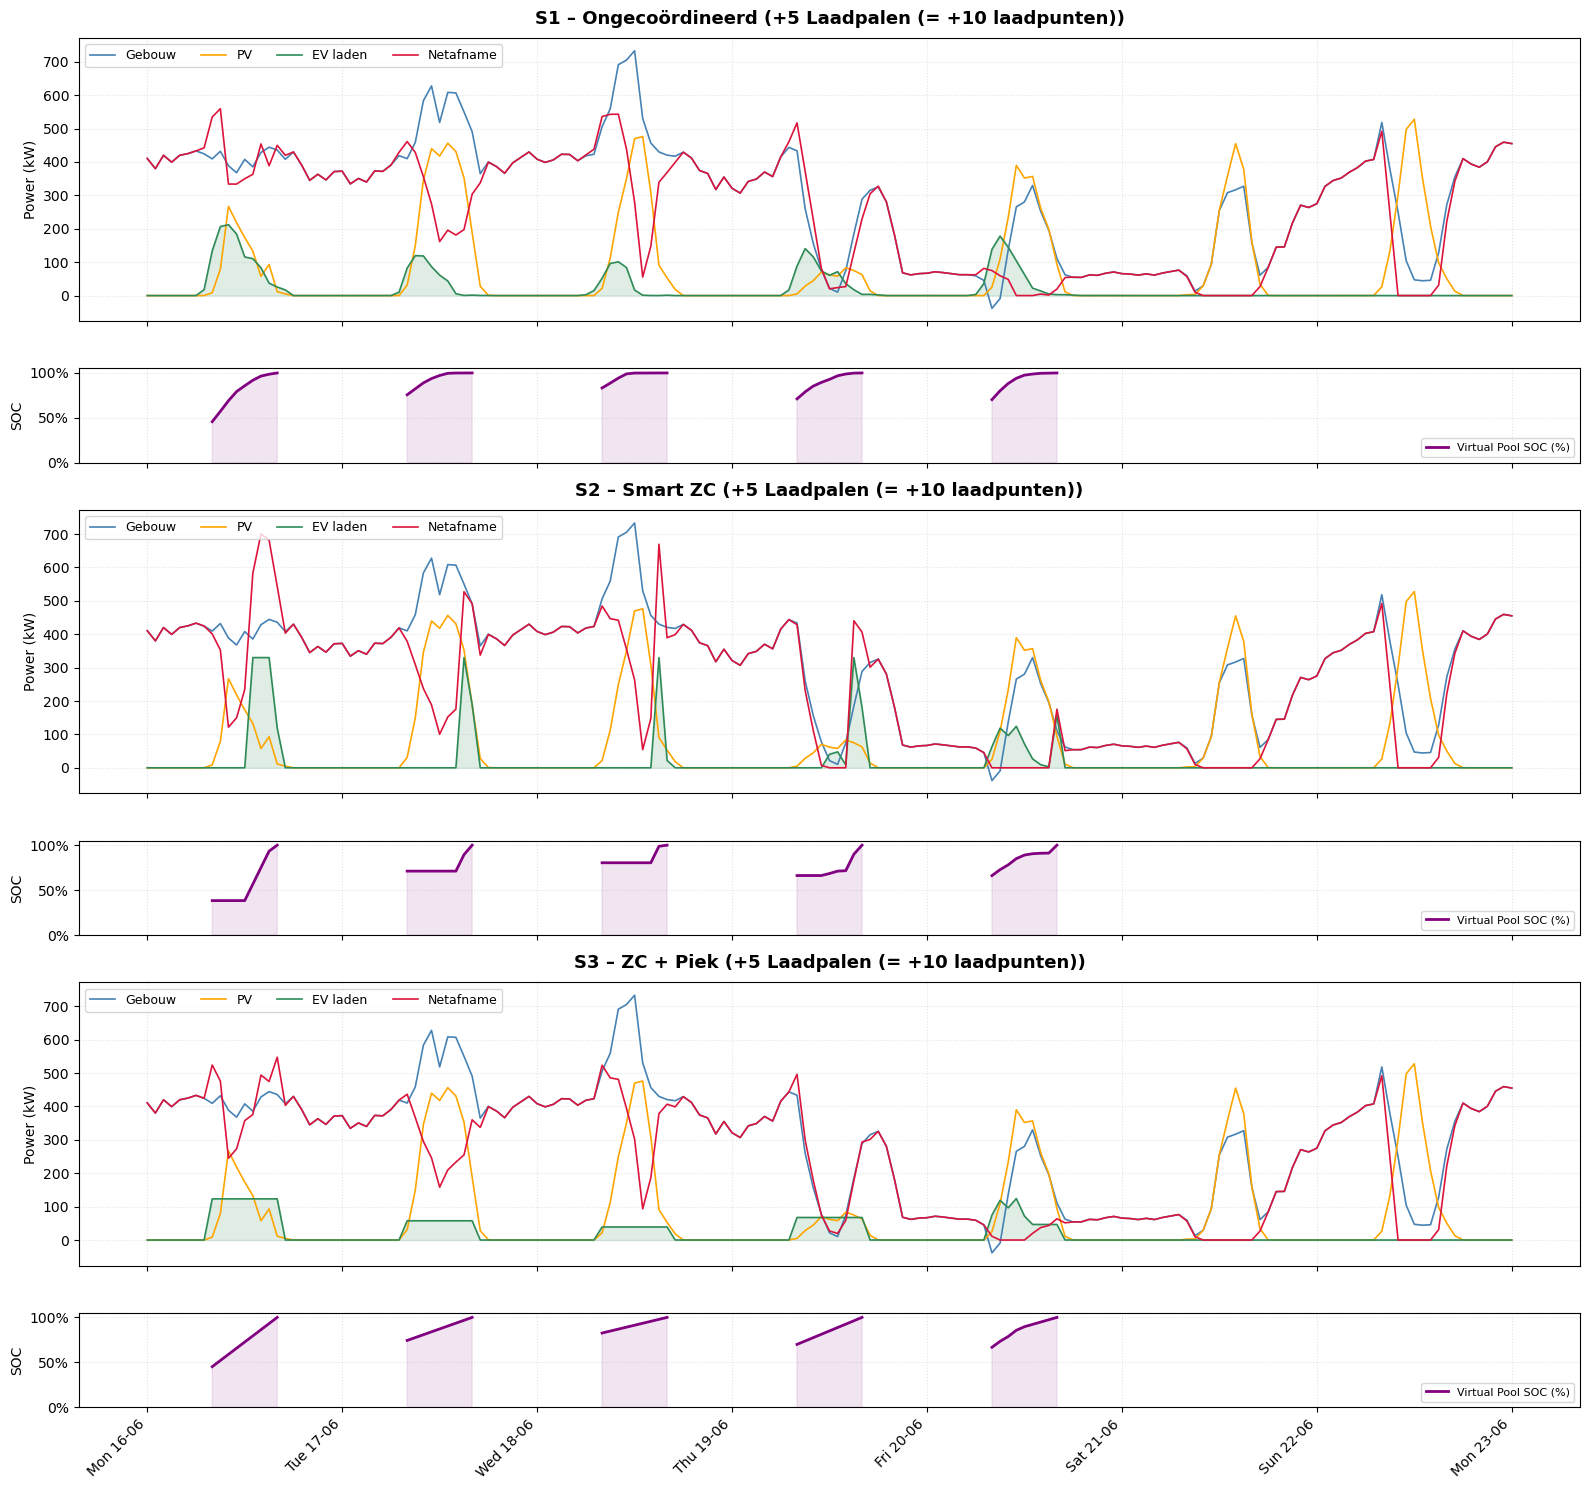

In [183]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np

# ============================================================
# INSTELLINGEN
# ============================================================
suffix_scenario = 'plus10p' 
naam_scenario = '+5 Laadpalen (= +10 laadpunten)' 
N_LAADPUNTEN_BASE = 20
EXTRA_LAADPUNTEN = 10
N_LAADPUNTEN_TOTAAL = N_LAADPUNTEN_BASE + EXTRA_LAADPUNTEN

# Controleer of deze overeenkomen met jouw notebook!
ACCU_KWH_PER_AUTO = 60  
TIJDSTAP_H = 1  
AANKOMST_H = 8
VERTREK_H = 17

# 1. ZOMERWEEK SELECTEREN (7 DAGEN)
start_plot = pd.Timestamp('2025-06-16 00:00:00') 
eind_plot = start_plot + pd.Timedelta(days=7) 
df_sim = df_main.loc[start_plot:eind_plot].copy()

# ============================================================
# VIRTUELE SOC BEREKENING (Onzichtbaar buiten werktijd)
# ============================================================
def bereken_virtuele_soc_week(df_tijd, col_laad, n_punten):
    totale_pool_kwh = n_punten * ACCU_KWH_PER_AUTO
    
    # FIX: Start met 'np.nan' zodat de grafiek leeg is als de auto's er niet zijn
    soc_series = pd.Series(np.nan, index=df_tijd.index) 
    
    factor = n_punten / N_LAADPUNTEN_BASE
    basis_behoefte = df_tijd['total_consumption_ev'] * factor
    werkdagen = df_tijd.index[df_tijd.index.dayofweek < 5].normalize().unique()
    
    for dag in werkdagen:
        mask_dag = (df_tijd.index.normalize() == dag)
        mask_aanwezig = mask_dag & (df_tijd.index.hour >= AANKOMST_H) & (df_tijd.index.hour < VERTREK_H)
        idx_aanwezig = df_tijd.index[mask_aanwezig]
        
        if len(idx_aanwezig) == 0:
            continue
            
        e_nodig_vandaag = basis_behoefte[idx_aanwezig].sum()
        
        # De start SOC berekenen
        huidige_energie = max(0.0, totale_pool_kwh - e_nodig_vandaag)
        
        for t in idx_aanwezig:
            p_geladen = df_tijd.loc[t, col_laad]
            huidige_energie += (p_geladen * TIJDSTAP_H)
            
            # Maximaal tot 100% laden
            huidige_energie = min(huidige_energie, totale_pool_kwh) 
            
            # We vullen de SOC nu alléén in voor de werkuren!
            soc_series[t] = (huidige_energie / totale_pool_kwh) * 100
            
        # We zetten hem 's avonds en in het weekend dus NIET meer op 100.
        # Deze uren blijven 'np.nan' en worden simpelweg niet getekend door Matplotlib.

    return soc_series

# ============================================================
# PLOTTEN (6 Subplots: 3x Power, 3x SOC)
# ============================================================
strategie_plot = {
    f'S1 – Ongecoördineerd ({naam_scenario})': (f'P_laad_S1_{suffix_scenario}', f'P_net_S1_{suffix_scenario}'),
    f'S2 – Smart ZC ({naam_scenario})': (f'P_laad_S2_{suffix_scenario}', f'P_net_S2_{suffix_scenario}'),
    f'S3 – ZC + Piek ({naam_scenario})': (f'P_laad_S3_{suffix_scenario}', f'P_net_S3_{suffix_scenario}'),
}

# Hoogteverhouding: Power grafiek = 3, SOC grafiek = 1
fig, axes = plt.subplots(6, 1, figsize=(16, 15), sharex=True, 
                         gridspec_kw={'height_ratios': [3, 1, 3, 1, 3, 1]})

ax_idx = 0
for naam, (col_laad, col_net) in strategie_plot.items():
    ax_power = axes[ax_idx]     # Boven: Power
    ax_soc = axes[ax_idx + 1]   # Onder: SOC
    
    gebouw = df_sim['totaal_verbruik_gebouw']
    pv = df_sim['productie_kwh']
    laad = df_sim[col_laad]
    net = df_sim[col_net]
    
    soc = bereken_virtuele_soc_week(df_sim, col_laad, N_LAADPUNTEN_TOTAAL)

    # --- 1. POWER GRAFIEK (kW) ---
    ax_power.plot(df_sim.index, gebouw, color='steelblue', linewidth=1.2, label='Gebouw')
    ax_power.plot(df_sim.index, pv, color='orange', linewidth=1.2, label='PV')
    ax_power.plot(df_sim.index, laad, color='seagreen', linewidth=1.2, label='EV laden')
    ax_power.plot(df_sim.index, net.clip(lower=0), color='crimson', linewidth=1.2, label='Netafname')
    ax_power.fill_between(df_sim.index, 0, laad, color='seagreen', alpha=0.15)
    
    ax_power.set_title(naam, fontsize=13, fontweight='bold', pad=10)
    ax_power.set_ylabel('Power (kW)')
    ax_power.grid(True, linestyle=':', alpha=0.35)
    ax_power.legend(loc='upper left', ncols=4, fontsize=9)

    # --- 2. SOC GRAFIEK (%) ---
    ax_soc.plot(df_sim.index, soc, color='purple', linewidth=2, label='Virtual Pool SOC (%)')
    # Omdat er hiaten in de data zitten (np.nan), zorgt Matplotlib er zelf voor
    # dat het opvullen netjes stopt bij de ontbrekende delen.
    ax_soc.fill_between(df_sim.index, 0, soc, color='purple', alpha=0.1)
    
    ax_soc.set_ylabel('SOC')
    ax_soc.set_ylim(0, 105)
    ax_soc.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_soc.grid(True, linestyle=':', alpha=0.35)
    ax_soc.legend(loc='lower right', fontsize=8)
    
    ax_idx += 2

# ============================================================
# X-AS OPMAAK VOOR EEN HELE WEEK
# ============================================================
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d-%m')) # Dag en Datum
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))      # Eén label per dag
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.subplots_adjust(hspace=0.25) 
plt.show()